# 03 — PSI comparison: Strict vs Variable 1nt

This notebook compares PSI values between the strict and variable 1nt boundary modes
for RI, A3, and A5 splicing events.

For each event type we look at three populations:
- **Shared events** — present in both modes; do PSI values change?
- **Variable-only events** — detected in variable but not in strict (Q1 + Q2)
- **Novel-transcript events** — non-ENSMUSG coordinate-based IDs (Q3)

Samples: KM1–KM3 = CT8 | KM4–KM6 = CT20 | KM7–KM9 = PerKO

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [2]:
# -- Helper functions --

def style_table(df, caption=""):
    """Apply consistent blue-header styling to a DataFrame for display."""
    styled = df.style\
        .set_properties(**{
            "font-size": "12px",
            "font-weight": "bold",
            "border": "1px solid #ddd",
            "padding": "6px 12px",
            "text-align": "center"
        })\
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#2196F3"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("padding", "6px 12px"),
                ("text-align", "center")
            ]},
            {"selector": "tr:nth-child(even)", "props": [
                ("background-color", "#f2f2f2")
            ]},
        ])\
        .hide(axis="index")
    if caption:
        styled = styled.set_caption(caption)
    return styled


def export_table_png(df, filepath, title=""):
    col_widths = []
    for col in df.columns:
        max_content = max(
            len(str(col)),
            df[col].astype(str).map(len).max()
        )
        col_widths.append(max_content)

    fig_width = max(sum(col_widths) * 0.15, 6)
    fig_height = len(df) * 0.6 + 0.8

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2196F3")
            cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")
        cell.set_edgecolor("#dddddd")
    if title:
        ax.set_title(title, fontsize=12, y=0.88)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved to {filepath}")


print("Helpers loaded!")

Helpers loaded!


In [3]:
# -- Paths --
BASE = "/Users/gricey/Desktop/Internship/data"

SAMPLES = ["KM1", "KM2", "KM3", "KM4", "KM5", "KM6", "KM7", "KM8", "KM9"]
CONDITIONS = {
    "CT8":   ["KM1", "KM2", "KM3"],
    "CT20":  ["KM4", "KM5", "KM6"],
    "PerKO": ["KM7", "KM8", "KM9"],
}

EVENT_TYPES = ["RI", "A3", "A5"]

In [4]:
# -- Load PSI files for all event types --

def load_psi(path):
    """Load a SUPPA PSI file, handling duplicate headers from variable mode."""
    df = pd.read_csv(path, sep="\t", index_col=0)
    # Drop any rows where the index looks like a header (e.g. 'KM1')
    df = df[~df.index.str.startswith("KM")]
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


psi = {}
for event in EVENT_TYPES:
    psi[("strict", event)]   = load_psi(f"{BASE}/output_strict/psi/{event}.psi")
    psi[("var1",   event)]   = load_psi(f"{BASE}/output_variable_1nt/psi/{event}.psi")
    print(f"{event}: strict={len(psi[('strict', event)])} events, "
          f"var1={len(psi[('var1', event)])} events")

RI: strict=5315 events, var1=17336 events
A3: strict=11163 events, var1=22931 events
A5: strict=9629 events, var1=19455 events


## Section 1 — Population counts

For each event type, split events into:
- **Shared** — event ID present in both strict and variable
- **Variable-only** — only in variable (ENSMUSG gene ID)
- **Novel** — only in variable, non-ENSMUSG coordinate-based ID

In [5]:
pop_rows = []

for event in EVENT_TYPES:
    strict_ids = set(psi[("strict", event)].index)
    var1_ids   = set(psi[("var1",   event)].index)

    shared         = strict_ids & var1_ids
    var_only        = var1_ids - strict_ids
    var_only_ensmusg = {e for e in var_only if e.startswith("ENSMUSG")}
    var_only_novel   = {e for e in var_only if not e.startswith("ENSMUSG")}

    pop_rows.append({
        "Event": event,
        "Shared (both modes)": len(shared),
        "Variable-only (ENSMUSG)": len(var_only_ensmusg),
        "Variable-only (novel ID)": len(var_only_novel),
        "Total strict": len(strict_ids),
        "Total variable": len(var1_ids),
    })

df_pop = pd.DataFrame(pop_rows)
display(style_table(df_pop, caption="PSI-level event populations: Strict vs Variable 1nt"))
export_table_png(df_pop, "../../figures/plots/table_psi_populations.png",
                 title="PSI-level event populations: Strict vs Variable 1nt")

Event,Shared (both modes),Variable-only (ENSMUSG),Variable-only (novel ID),Total strict,Total variable
RI,0,17335,1,5315,17336
A3,0,22931,0,11163,22931
A5,0,19455,0,9629,19455


Saved to ../../figures/plots/table_psi_populations.png


## Section 2 — PSI shift for shared events

For events present in **both** modes, compute the mean absolute PSI difference
across all samples: `|PSI_variable - PSI_strict|`.

This tells us whether relaxing the boundary changes the quantification
for events that both modes detect.

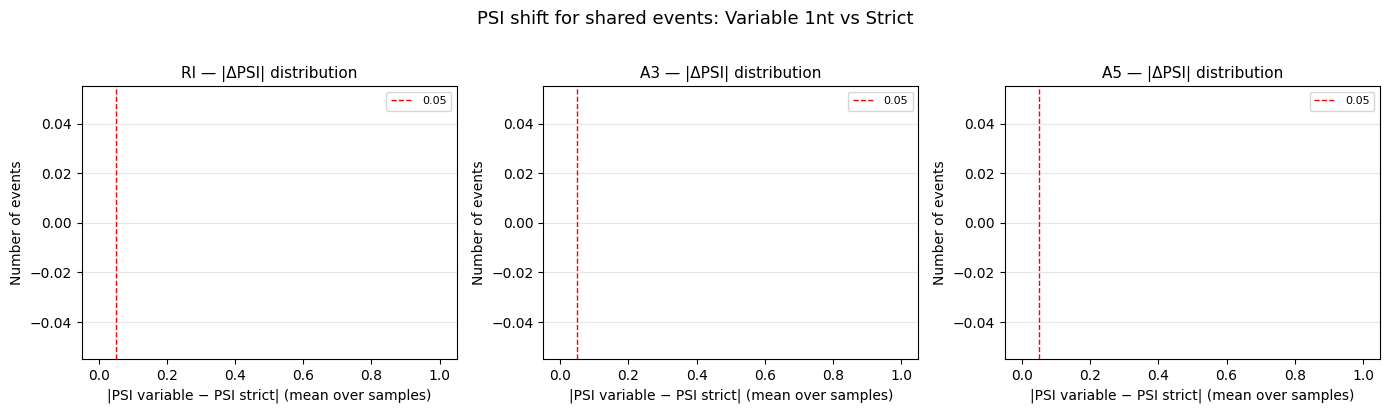

Saved!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
muted = sns.color_palette("muted", 3)

shift_summary = []

for i, event in enumerate(EVENT_TYPES):
    strict_df = psi[("strict", event)]
    var1_df   = psi[("var1",   event)]

    shared = strict_df.index.intersection(var1_df.index)

    diff = (var1_df.loc[shared] - strict_df.loc[shared]).abs()
    mean_diff_per_event = diff.mean(axis=1)   # mean across 9 samples

    # Drop NaN (events where both modes had NaN)
    mean_diff_per_event = mean_diff_per_event.dropna()

    shift_summary.append({
        "Event": event,
        "Shared events": len(shared),
        "Events with PSI shift > 0.01": int((mean_diff_per_event > 0.01).sum()),
        "Events with PSI shift > 0.05": int((mean_diff_per_event > 0.05).sum()),
        "Median |ΔPSI|": f"{mean_diff_per_event.median():.4f}",
        "Max |ΔPSI|": f"{mean_diff_per_event.max():.4f}",
    })

    ax = axes[i]
    ax.hist(mean_diff_per_event, bins=50, color=muted[i], edgecolor="white", linewidth=0.3)
    ax.set_title(f"{event} — |ΔPSI| distribution", fontsize=11)
    ax.set_xlabel("|PSI variable − PSI strict| (mean over samples)")
    ax.set_ylabel("Number of events")
    ax.axvline(0.05, color="red", linestyle="--", linewidth=1, label="0.05")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("PSI shift for shared events: Variable 1nt vs Strict", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/hist_psi_shift_shared.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [7]:
# Summary table for PSI shift
df_shift = pd.DataFrame(shift_summary)
display(style_table(df_shift, caption="PSI shift summary for shared events"))
export_table_png(df_shift, "../../figures/plots/table_psi_shift.png",
                 title="PSI shift summary for shared events")

Event,Shared events,Events with PSI shift > 0.01,Events with PSI shift > 0.05,Median |ΔPSI|,Max |ΔPSI|
RI,0,0,0,nan,nan
A3,0,0,0,nan,nan
A5,0,0,0,nan,nan


Saved to ../../figures/plots/table_psi_shift.png


## Section 3 — PSI distribution for variable-only events

For events **only detected in variable mode**, look at their mean PSI per condition.
If they have non-zero PSI, they are biologically expressed and missed by strict.

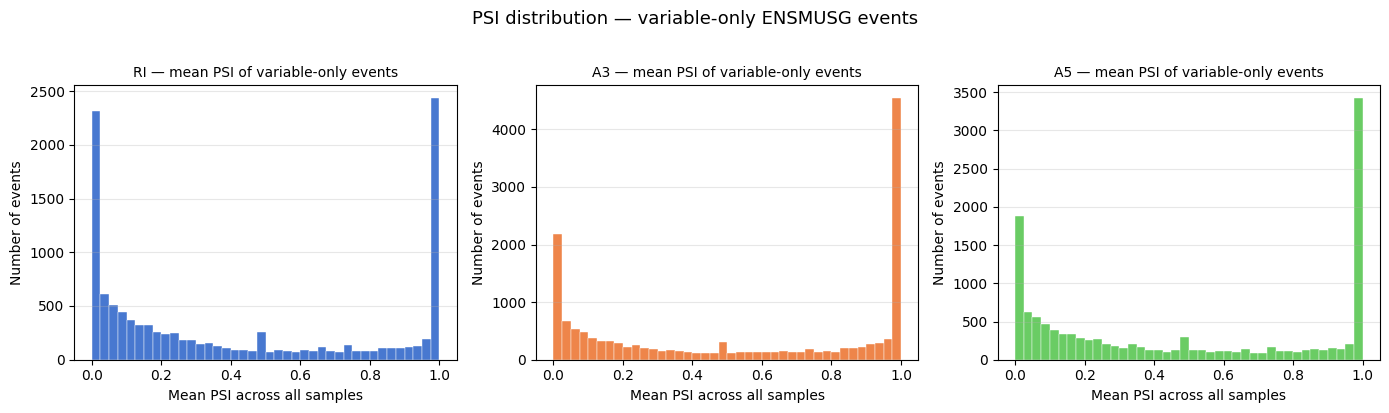

Saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

varonly_summary = []

for i, event in enumerate(EVENT_TYPES):
    strict_ids = set(psi[("strict", event)].index)
    var1_df    = psi[("var1",   event)]

    var_only_ids = [idx for idx in var1_df.index
                    if idx not in strict_ids and idx.startswith("ENSMUSG")]
    var_only_df  = var1_df.loc[var_only_ids]

    # Mean PSI per event across all samples (ignore NaN)
    mean_psi = var_only_df.mean(axis=1).dropna()

    # How many have at least some expression (mean PSI > 0)?
    n_expressed = int((mean_psi > 0).sum())
    n_all_nan   = int(var_only_df.isna().all(axis=1).sum())

    varonly_summary.append({
        "Event": event,
        "Variable-only events (ENSMUSG)": len(var_only_ids),
        "All-NaN (no TPM support)": n_all_nan,
        "Mean PSI > 0 (expressed)": n_expressed,
        "Mean PSI = 0 (not used)": int((mean_psi == 0).sum()),
    })

    ax = axes[i]
    ax.hist(mean_psi[mean_psi > 0], bins=40, color=muted[i], edgecolor="white", linewidth=0.3)
    ax.set_title(f"{event} — mean PSI of variable-only events", fontsize=10)
    ax.set_xlabel("Mean PSI across all samples")
    ax.set_ylabel("Number of events")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("PSI distribution — variable-only ENSMUSG events", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/hist_psi_varonly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [9]:
# Summary table for variable-only events
df_varonly = pd.DataFrame(varonly_summary)
display(style_table(df_varonly, caption="Variable-only events: expression status"))
export_table_png(df_varonly, "../../figures/plots/table_psi_varonly.png",
                 title="Variable-only events: expression status")

Event,Variable-only events (ENSMUSG),All-NaN (no TPM support),Mean PSI > 0 (expressed),Mean PSI = 0 (not used)
RI,17335,2384,11389,3562
A3,22931,3966,15222,3743
A5,19455,3040,12916,3499


Saved to ../../figures/plots/table_psi_varonly.png


## Section 4 — Per-condition PSI: shared vs variable-only

For each condition (CT8, CT20, PerKO), compare the mean PSI of:
- shared events (detected in both modes)
- variable-only events (new in variable)

This shows whether the newly detected events have comparable expression levels
or are systematically lower (weaker events missed by strict).

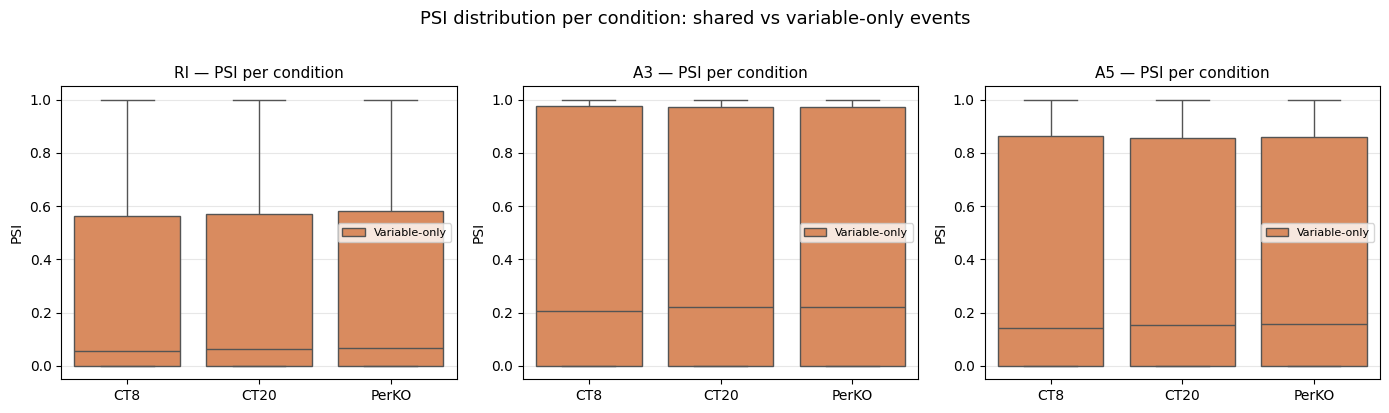

Saved!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, event in enumerate(EVENT_TYPES):
    strict_df  = psi[("strict", event)]
    var1_df    = psi[("var1",   event)]

    shared_ids   = list(strict_df.index.intersection(var1_df.index))
    var_only_ids = [idx for idx in var1_df.index
                    if idx not in set(strict_df.index) and idx.startswith("ENSMUSG")]

    rows = []
    for cond, samples in CONDITIONS.items():
        shared_psi  = var1_df.loc[shared_ids, samples].values.flatten()
        varonly_psi = var1_df.loc[var_only_ids, samples].values.flatten()

        for v in shared_psi[~np.isnan(shared_psi)]:
            rows.append({"Condition": cond, "Population": "Shared", "PSI": v})
        for v in varonly_psi[~np.isnan(varonly_psi)]:
            rows.append({"Condition": cond, "Population": "Variable-only", "PSI": v})

    df_plot = pd.DataFrame(rows)

    ax = axes[i]
    sns.boxplot(
        data=df_plot, x="Condition", y="PSI", hue="Population",
        palette={"Shared": muted[0], "Variable-only": muted[1]},
        showfliers=False, ax=ax
    )
    ax.set_title(f"{event} — PSI per condition", fontsize=11)
    ax.set_ylabel("PSI")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("PSI distribution per condition: shared vs variable-only events",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/boxplot_psi_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")